In [1]:
from typing import List, Dict
import random
import plotly.express as px
import pandas as pd
import time
import timeit

In [2]:
#pd.options.mode.chained_assignment = None

def generate_random_data(element_count:int=250):
    return sorted([random.randint(100, 100000000) for _ in range(element_count)])

def binary_search_driver(sorted_array:List[int], value:int) -> List[Dict]:
    global intermediate_results
    # Dictionary 4 elements - iteration count, left pointer, right pointer, if the searched value is found
    intermediate_results = [{
        'iteration_count': 0, 
        'left': 0, 
        'right': len(sorted_array) - 1,
        'found': False
    }]
    
    def binary_search(sorted_array:List[int], left:int, right:int, value:int)->int:
        p = intermediate_results[len(intermediate_results) - 1]['iteration_count'] + 1
        if left > right:
            intermediate_results.append(
                {'iteration_count': p,
                 'left': left,
                 'right': right,
                 'found': False
                })
            return -1
        mid = (left + right) // 2
        if sorted_array[mid] == value:
            intermediate_results.append(
                {'iteration_count': p,
                 'left': mid,
                 'right': mid,
                 'found': True
                })
            return mid
        elif sorted_array[mid] > value:
            intermediate_results.append(
                {'iteration_count': p,
                 'left': left,
                 'right': mid - 1,
                 'found': False
                })            
            return binary_search(sorted_array, left, mid - 1, value)
        else:
            intermediate_results.append(
                {'iteration_count': p,
                 'left': mid + 1,
                 'right': right,
                 'found': False
                })  
            return binary_search(sorted_array, mid + 1, right, value)

    binary_search(sorted_array, 0 , len(sorted_array) - 1, value)
    return intermediate_results



In [3]:
def animate_binary_search(sorted_array:List[int], progress:List[Dict], value:int)->None:
    df = pd.DataFrame()
    
    for p in progress:
        df1 = pd.DataFrame([[p['iteration_count'], i, e, 'other'] for i, e in enumerate(sorted_array)], columns=['iteration', 'index', 'value', 'category'])
        if p['found']:
            df1.loc[df1.index == p['left'], 'category'] = 'found'
        else:
            df1.loc[df1.index == p['left'], 'category'] = 'left'
            df1.loc[df1.index == p['right'], 'category'] = 'right'
        df = pd.concat([df, df1])
        
    fig = px.bar(
        df, 
        x="index", 
        y="value", 
        animation_frame="iteration", 
        color='category',
        width=1000, 
        height=600,
        title="Binary search for %d" % value)
    fig.update(layout_yaxis_range = [0, max(df.value) + 100])
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 2000
    fig.show('svg')
    


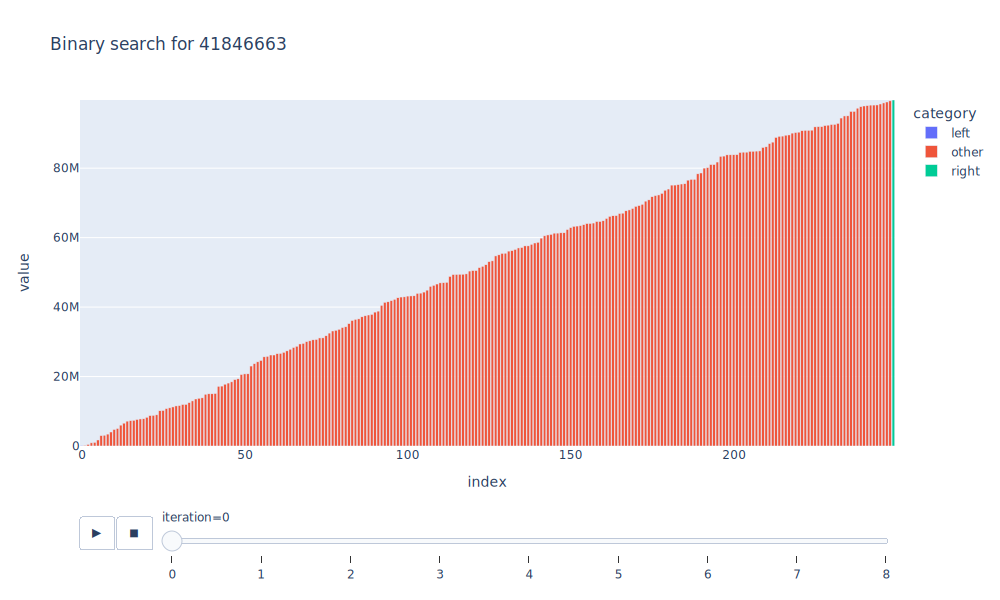

In [4]:
# Search of value which is in 95-th position of sorted array
sorted_array = generate_random_data()
value = sorted_array[95]
progress = binary_search_driver(sorted_array, value)
animate_binary_search(sorted_array, progress, value)


In [5]:
# Helper routine to find a random integer not present in a list of intergers
def random_exclude(exclusion:List[int])->int:
    exclusion = set(exclusion)
    num = random.randint(100, 100000000)
    return random_exclude(exclusion) if num in exclusion else num



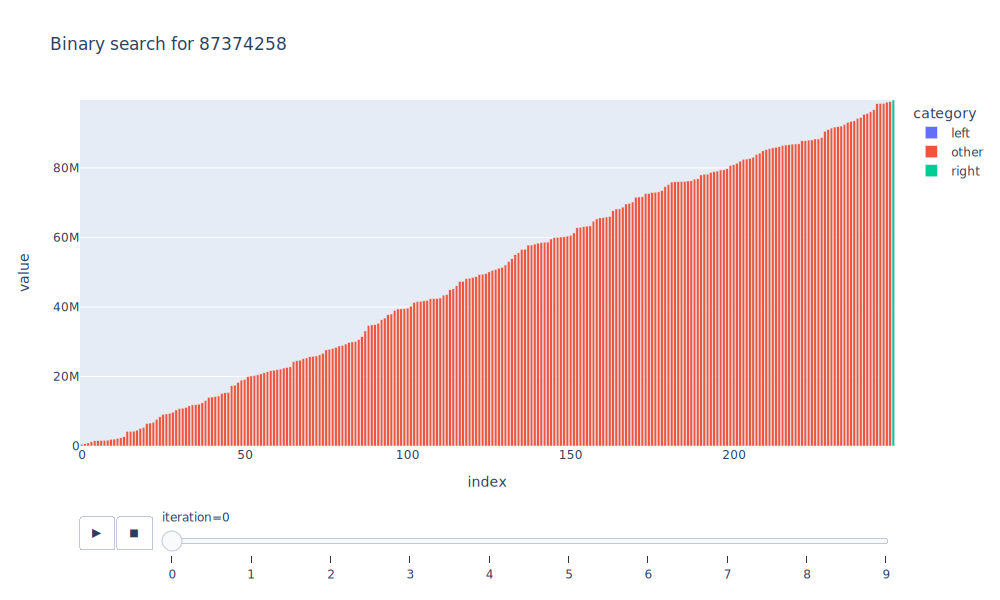

In [6]:
# Search for a value that is not present in the sorted array
sorted_array = generate_random_data()
value = random_exclude(sorted_array)
progress = binary_search_driver(sorted_array, value)
animate_binary_search(sorted_array, progress, value)


In [7]:


# Partition the array in n segments
def get_partitions(l:int, h:int, n:int):
    partitions = []
    for i in range(n):
        partitions.append(((n - i) * l + i * h) // n)
    partitions.append(h)
    return partitions

# Check if the searched value exists at partition points
# Returns adjusted partition boundaries
def find_value(sorted_array, partitions, value):
    for i in range(1, len(partitions) - 1):
        if sorted_array[partitions[i]] == value:
            return True, partitions[i], partitions[i]
    if value < sorted_array[partitions[1]]:
        return False, partitions[0], partitions[1] - 1
    elif value > sorted_array[partitions[-2]]:
        return False, partitions[-2] + 1, partitions[-1]

    for i in range(1, len(partitions) - 1):
        if sorted_array[partitions[i]] < value < sorted_array[partitions[i + 1]]:
            return False, partitions[i] + 1, partitions[i + 1] - 1 
        
def animate_n_way_search_driver(sorted_array:List[int], value:int, n_way:int)->List[Dict]:
    global intermediate_results
    # Tuple of 4 elements - iteration count, left pointer, right pointer, if the searched value is found
    intermediate_results = [{
        'iteration_count': 0, 
        'left': 0, 
        'right': len(sorted_array) - 1,
        'found': False
    }]
        
    def n_way_search(sorted_array:List[int], left:int, right:int, value:int, n:int)->int:
        global intermediate_results
        p = intermediate_results[len(intermediate_results) - 1]['iteration_count'] + 1
        if left > right:
            intermediate_results.append({
                'iteration_count': p, 
                'left': 0, 
                'right': len(sorted_array) - 1,
                'found': False
            })           
            return -1
        partitions = get_partitions(left, right, n)
        found, adjusted_left, adjusted_right = find_value(sorted_array, partitions, value)
        if found:
            intermediate_results.append({
                'iteration_count': p, 
                'left': adjusted_left, 
                'right': adjusted_left,
                'found': True
            }) 
            return adjusted_left
        else:
            intermediate_results.append({
                'iteration_count': p, 
                'left': adjusted_left, 
                'right': adjusted_right,
                'found': False
            }) 
            return n_way_search(sorted_array, adjusted_left, adjusted_right, value, n)
    
    index = n_way_search(sorted_array, 0, len(sorted_array) - 1, value, n_way)
    assert value == sorted_array[index]
    return intermediate_results
    

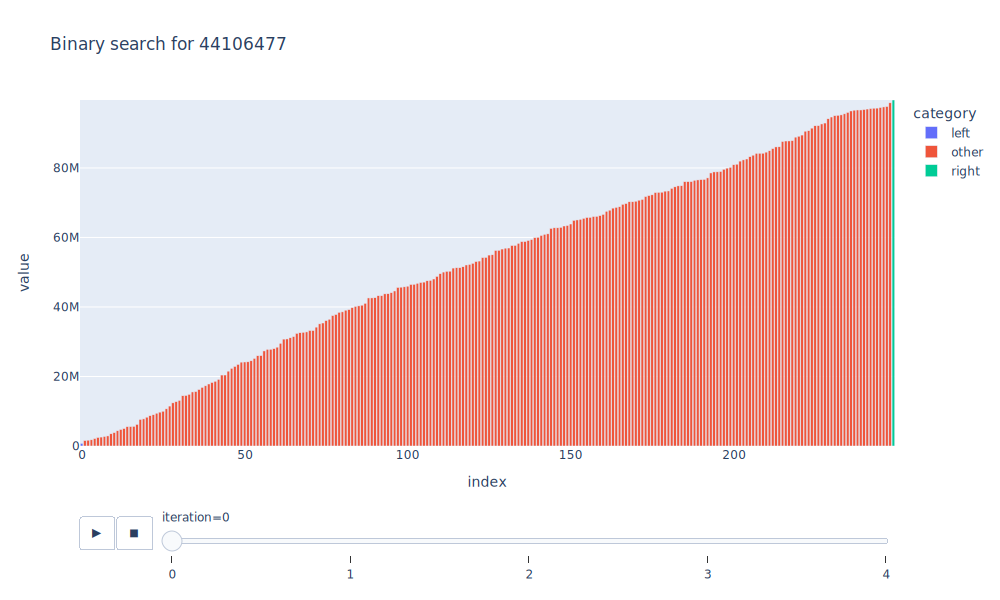

In [8]:
sorted_array = generate_random_data()
value = sorted_array[95]
n_way = 3
progress = animate_n_way_search_driver(sorted_array, value, n_way)
animate_binary_search(sorted_array, progress, value)


In [9]:
def n_way_search(sorted_array:List[int], left:int, right:int, value:int, n:int)->int:
    print(left, right, sorted_array[left], sorted_array[right])
    if left > right:         
        return -1
    partitions = get_partitions(left, right, n)
    print(partitions)
    found, adjusted_left, adjusted_right = find_value(sorted_array, partitions, value)
    if found:
        return adjusted_left
    else:
        return n_way_search(sorted_array, adjusted_left, adjusted_right, value, n)



In [11]:

# Binary search
def binary_search(sorted_array:List[int], left:int, right:int, value:int)->int:
    if left > right:
        return -1
    mid = (left + right) // 2
    if sorted_array[mid] == value:
        return mid
    elif sorted_array[mid] > value:
        return binary_search(sorted_array, left, mid - 1, value)
    else:
        return binary_search(sorted_array, mid + 1, right, value)

def generate_random_data(element_count:int=250):
    return sorted([random.randint(100, 100000000) for i in range(element_count)])


def n_way_search(sorted_array:List[int], left:int, right:int, value:int, n:int)->int:
    if left > right:
        return -1
    partitions = get_partitions(left, right, n)
    found, adjusted_left, adjusted_right = find_value(sorted_array, partitions, value)
    if found:
        return adjusted_left
    else:
        return n_way_search(sorted_array, adjusted_left, adjusted_right, value, n)



In [17]:
# Execute n-way searches for different array size
# Input Paramaters:
#    n_way: allowable values 3,4,5 etc
#    start_array_size: Starting array size to run the experiment
#    end_array_size: Ending array size to run the experiment
#    array_size_incr: Step size for incrementing array size
#    num_searches: Number of searches executed. e.g. 20
#                  means 20 random values are searched
#    value_present: booelan. Allowable values True / False
#                   True means searched values exist in the array
#                   False menas searched values do not exist in the array
#    repeat: int. Number of times timeit test is repeated
#
def run_nway_search(n_way: int, 
                    value_present: bool, 
                    start_array_size:int=1000000, 
                    end_array_size:int=11000001, 
                    array_size_incr:int=500000,
                    num_searches:int=50,
                    repeat:int=500)->pd.DataFrame:
    cpu_time = []
    for num_element in range(start_array_size, end_array_size, array_size_incr):
        sorted_array = generate_random_data(num_element)
        for r in range(num_searches):
            if value_present:
                value = sorted_array[random.randint(0, num_element - 1)]
            else:
                value = random_exclude(sorted_array)
            right = len(sorted_array) - 1

            if n_way == 2:
                # total time taken to run the test
                t = timeit.Timer(lambda: binary_search(
                    sorted_array=sorted_array,
                    left=0,
                    right=right,
                    value=value)).timeit(repeat)
            else:
                t = timeit.Timer(lambda: n_way_search(
                    sorted_array=sorted_array,
                    left=0,
                    right=right,
                    value=value,
                    n=n_way)).timeit(repeat)
            
            cpu_time.append([num_element,
                             n_way,
                             t,
                             value,
                             value_present])
            
    return pd.DataFrame(cpu_time,
                        columns=['record_count', 'n_way', 'time_taken', 'value', 'value_present'])



In [18]:
df = pd.DataFrame()
for n_way in range(2, 9):
    for value_present in [True, False]:
        print('Collecting timing for %d-way search with search value %s' % (n_way, 'present' if value_present else 'absent'))
        df = pd.concat([df, run_nway_search(n_way, value_present)])
        

In [45]:
# Display line graph showing cumulative time taken 
# Since time taken is tracked for every value searched
# so median value of all such searches is used here
fig = px.line(
    df.query("n_way in [2,4,6,8]") \
      .groupby(['record_count', 'n_way', 'value_present']) \
      .agg({'time_taken': 'median'}) \
      .reset_index(), 
    x="record_count", 
    y="time_taken", 
    color="n_way", 
    title='Time taken by m-way search (measured by timeit)',
    facet_col="value_present",
    facet_col_spacing=0.04,
    labels = {
        'time_taken': 'Time taken (sec/500 executions)',
        'n_way': 'm-way',
        'record_count': 'Array size',
        'value_present': 'Search value exists?'
    },
    
)
fig.show()


In [54]:
fig = px.histogram(
    df.query("n_way == 2 or n_way == 3"), 
    x='time_taken', 
    color='value_present',
    labels = {
        'time_taken': 'Time taken (sec/500 executions)',
        'value_present': 'Search value exists?',
        'n_way': 'm-way'
    },
    title='Histogram of time taken by m-way search (measured by timeit)',
    facet_col="n_way",
    facet_col_spacing=0.04,
)
fig.update_yaxes(matches=None)
fig.for_each_yaxis(lambda yaxis: yaxis.update(showticklabels=True))
fig.show()